# Module 2.3 — Market Data & Infrastructure
## The Nervous System of Quantitative Finance

---

### On the Nature of Financial Data

There is a quiet paradox at the heart of quantitative finance: the markets are among the most observed phenomena in human history, yet they remain among the least understood. Every microsecond, exchanges emit torrents of data—prices, volumes, order insertions, cancellations—a ceaseless pulse that records the collective behavior of millions of participants. This data is the **raw material of every quantitative strategy ever conceived**. Without it, your models are philosophy; with it, they become engineering. The difference between a profitable quant and a bankrupt one is not always intelligence or creativity—it is often the quality, granularity, and timeliness of the data they consume.

But data is not neutral. Every dataset carries the fingerprints of its creation: the exchange that generated it, the vendor that cleaned (or failed to clean) it, the protocol that transmitted it, the database that stored it, the query that retrieved it. Each layer introduces latency, bias, and potential error. **Survivorship bias** silently removes failed companies from historical datasets. **Look-ahead bias** lets future information leak into past observations. **Stale prices** masquerade as current ones. The infrastructure you build to collect, store, and serve market data is not merely plumbing—it is the **epistemological foundation** of your entire research and trading operation. A model is only as trustworthy as the data that trains it, and a live strategy is only as fast as the infrastructure that feeds it.

This module treats data infrastructure with the seriousness it deserves. We will move from the taxonomy of market data types—tick data, bar data, fundamental data—through the ecosystem of vendors and APIs, the protocols that move bits across networks, and finally to the storage systems and pipelines that transform raw market events into the structured, query-ready datasets your strategies depend on. Along the way, we will build working implementations: data pipelines, OHLCV aggregators, streaming simulators, and a backtesting-ready data warehouse. By the end, you will understand not just *what* market data is, but *why* it takes the forms it does, *where* the hidden dangers lie, and *how* to build infrastructure that you can trust with real capital.

---

### Learning Objectives

By the end of this module, you will:

1. **Distinguish** tick, bar, and fundamental data—and understand the information lost in each aggregation
2. **Navigate** the landscape of data vendors and APIs (Bloomberg, Reuters, Polygon, Yahoo Finance)
3. **Understand** exchange connectivity protocols (FIX, REST, WebSocket) and their trade-offs
4. **Design** data storage schemas for SQL, NoSQL, and time-series databases
5. **Build** data pipelines that transform raw market events into structured datasets
6. **Implement** real-time data streaming simulations in Python
7. **Construct** a data warehouse architecture suitable for backtesting at scale
8. **Recognize** and defend against common data pitfalls: survivorship bias, look-ahead bias, and data snooping

---

### Module Contents

1. **The Taxonomy of Market Data** — Tick, bar, and fundamental: what is preserved and what is lost
2. **Data Vendors & the API Ecosystem** — From Bloomberg terminals to open-source feeds
3. **Exchange Connectivity & Protocols** — FIX, REST, WebSocket: the language machines speak
4. **Data Storage & Database Design** — SQL, time-series databases, and the architecture of memory
5. **Building Data Pipelines** — From raw events to research-ready datasets
6. **Real-Time Streaming** — Simulating the live data experience
7. **The Backtesting Data Warehouse** — Infrastructure for rigorous strategy evaluation
8. **Data Integrity & Bias** — The silent enemies of every quantitative researcher

---

*"In God we trust; all others must bring data." — W. Edwards Deming*

*In quantitative finance, even data must earn its trust.*

In [3]:
# ========================================
# Initial Setup and Configuration
# ========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from typing import List, Dict, Tuple, Optional, Any, Generator
from dataclasses import dataclass, field
from enum import Enum
from datetime import datetime, timedelta
from collections import deque, defaultdict
import warnings
import json
import hashlib
import time
import sqlite3
import io
import abc

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

PLOT_CONFIG = {
    'figure.figsize': (14, 7),
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 100,
    'lines.linewidth': 2,
}
plt.rcParams.update(PLOT_CONFIG)

COLORS = {
    'tick': '#1565C0',
    'bar': '#2E7D32',
    'fundamental': '#F57C00',
    'bid': '#2E7D32',
    'ask': '#C62828',
    'volume': '#6A1B9A',
    'latency': '#D32F2F',
    'neutral': '#455A64',
    'pipeline': '#00838F',
    'storage': '#4527A0',
}

print("=" * 80)
print(" " * 16 + "MODULE 2.3: MARKET DATA & INFRASTRUCTURE")
print("=" * 80)
print(f"✓ Environment configured successfully")
print(f"✓ Random seed: {RANDOM_SEED}")
print(f"✓ NumPy version: {np.__version__}")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)
print("\n📚 Ready to build the nervous system of quantitative finance!\n")

                MODULE 2.3: MARKET DATA & INFRASTRUCTURE
✓ Environment configured successfully
✓ Random seed: 42
✓ NumPy version: 2.4.3
✓ Pandas version: 3.0.1
✓ Timestamp: 2026-03-20 22:15:42

📚 Ready to build the nervous system of quantitative finance!



---

## 1. The Taxonomy of Market Data

### 1.1 Tick Data: The Atomic Unit of Market Information

Every journey into market data begins with the **tick**—the smallest, most granular record of a market event. A tick captures a single occurrence: a trade executed, a quote updated, an order placed or cancelled. In its purest form, a tick is a timestamp paired with a price and a quantity. It is the atom of the financial data universe, and like atoms, its simplicity is deceptive. A single day on a liquid exchange can generate **hundreds of millions** of ticks. The full tick stream of the U.S. equity market produces roughly 10-50 GB of data per day, compressed.

Why does tick data matter? Because every higher-level representation—every candlestick chart, every daily close, every moving average—is a **lossy compression** of the tick stream. When you aggregate ticks into 1-minute bars, you discard the sequence of trades within that minute, the micro-patterns of buying and selling pressure, the fleeting moments of illiquidity. For most strategies, this loss is acceptable. For others—particularly those operating at high frequency or those studying market microstructure—it is fatal. The decision of what resolution to work at is not merely technical; it is a statement about what information you believe matters.

Tick data comes in several flavors:

- **Trade ticks**: Records of executed trades (timestamp, price, volume, aggressor side)
- **Quote ticks (NBBO)**: Best bid and ask prices with their sizes, updated on every change
- **Order book snapshots**: Full depth-of-book at regular intervals (L2/L3 data)
- **Order-by-order data**: Individual order insertions, modifications, and cancellations

Each level reveals more about the market's state but demands exponentially more storage and processing power.

### 1.2 Bar Data: The Art of Aggregation

Bar data (also called candlestick or OHLCV data) aggregates ticks into fixed intervals: 1-second, 1-minute, 5-minute, hourly, daily. Each bar records the **Open, High, Low, Close** prices and the total **Volume** traded during the interval. Bars are the lingua franca of technical analysis and the default input to most quantitative models. They are convenient, compact, and intuitive. But this convenience comes at a philosophical cost: bars impose a **time-based sampling** on a phenomenon that is fundamentally **event-driven**.

Consider a 1-minute bar during the open of a volatile earnings day versus a 1-minute bar during a quiet afternoon. Both cover 60 seconds, but the first might contain 5,000 trades and violent price swings, while the second contains 12 trades and a fraction of a cent of movement. Treating them as equivalent observations—as most time-series models implicitly do—is a category error. This insight has led to the development of alternative bar types:

- **Time bars**: Standard OHLCV at fixed time intervals (1m, 5m, 1h, 1d)
- **Tick bars**: A new bar forms every $N$ trades (e.g., every 100 trades)
- **Volume bars**: A new bar forms every $V$ units of volume traded
- **Dollar bars**: A new bar forms every $D$ dollars transacted
- **Imbalance bars**: A new bar forms when order flow imbalance exceeds a threshold

Marcos López de Prado argues in *Advances in Financial Machine Learning* that volume and dollar bars produce returns that are closer to IID (independent and identically distributed), a property that makes them more amenable to statistical modeling. The choice of bar type is not neutral—it shapes the statistical properties of the data your model consumes.

### 1.3 Fundamental Data: The Slow Pulse of Value

While tick and bar data record the fast heartbeat of price action, **fundamental data** captures the slow pulse of economic value. Financial statements, earnings reports, macroeconomic indicators, analyst estimates, corporate actions—these are the data that value investors and fundamental quants consume. Fundamental data arrives on a different timescale: quarterly earnings, monthly employment reports, annual filings. It is sparse, irregularly spaced, and subject to **revisions** (GDP figures, for example, are revised multiple times after initial release).

The challenge with fundamental data is **point-in-time accuracy**. When you backtest a strategy that uses earnings data, you must ensure that your model only sees the earnings figures that were actually available at each historical point. Using revised figures that weren't published until months later introduces look-ahead bias. The distinction between the *initial release* and the *final revised figure* can be substantial—and can mean the difference between a strategy that works in backtest and one that works in reality.

Key categories of fundamental data:

- **Financial statements**: Income statement, balance sheet, cash flow statement
- **Earnings data**: EPS, revenue, guidance, analyst estimates and surprises
- **Corporate actions**: Dividends, splits, mergers, spin-offs, delistings
- **Macroeconomic**: GDP, CPI, unemployment, interest rates, PMI
- **Alternative data**: Satellite imagery, credit card transactions, web traffic, sentiment

---

### Mathematical Framework: Information Loss in Aggregation

Given a sequence of $N$ trade ticks $\{(t_i, p_i, v_i)\}_{i=1}^{N}$ within a bar interval, the OHLCV bar retains only:

$$\text{Open} = p_1, \quad \text{High} = \max_i p_i, \quad \text{Low} = \min_i p_i, \quad \text{Close} = p_N, \quad \text{Volume} = \sum_i v_i$$

The **information entropy** of the original tick sequence is:

$$H(\text{ticks}) = -\sum_{i} P(p_i) \log_2 P(p_i)$$

while the bar compresses this to at most $5 \log_2(\text{precision})$ bits. For a typical bar, the **compression ratio** is:

$$\rho = \frac{5}{N \cdot k}$$

where $k$ is the number of fields per tick. For a bar containing 1,000 ticks with 4 fields each, $\rho \approx 0.00125$—we retain roughly **0.1%** of the original information. Every model built on bar data implicitly assumes the other 99.9% is noise.

TICK DATA GENERATION
Symbol: AAPL
Duration: 1 hour (09:30 - 10:30)
Total ticks generated: 28,828
Avg ticks/second: 8.0
Price range: $182.00 — $186.74
Total volume: 5,283,906 shares
Total dollar volume: $976,908,786

Bar Type                Count   Avg Trades/Bar   Info Retained
--------------------------------------------------------------
Raw Ticks              28,828              1.0         1.0000
1-min Time Bars            60            480.5         0.0026
5-min Time Bars            12           2402.3         0.0005
100-Tick Bars             289            100.0         0.0125
Volume Bars (50k)         106            272.0         0.0046
Dollar Bars ($10M)         98            294.2         0.0042

💡 Lower 'Info Retained' = more compression = more information lost


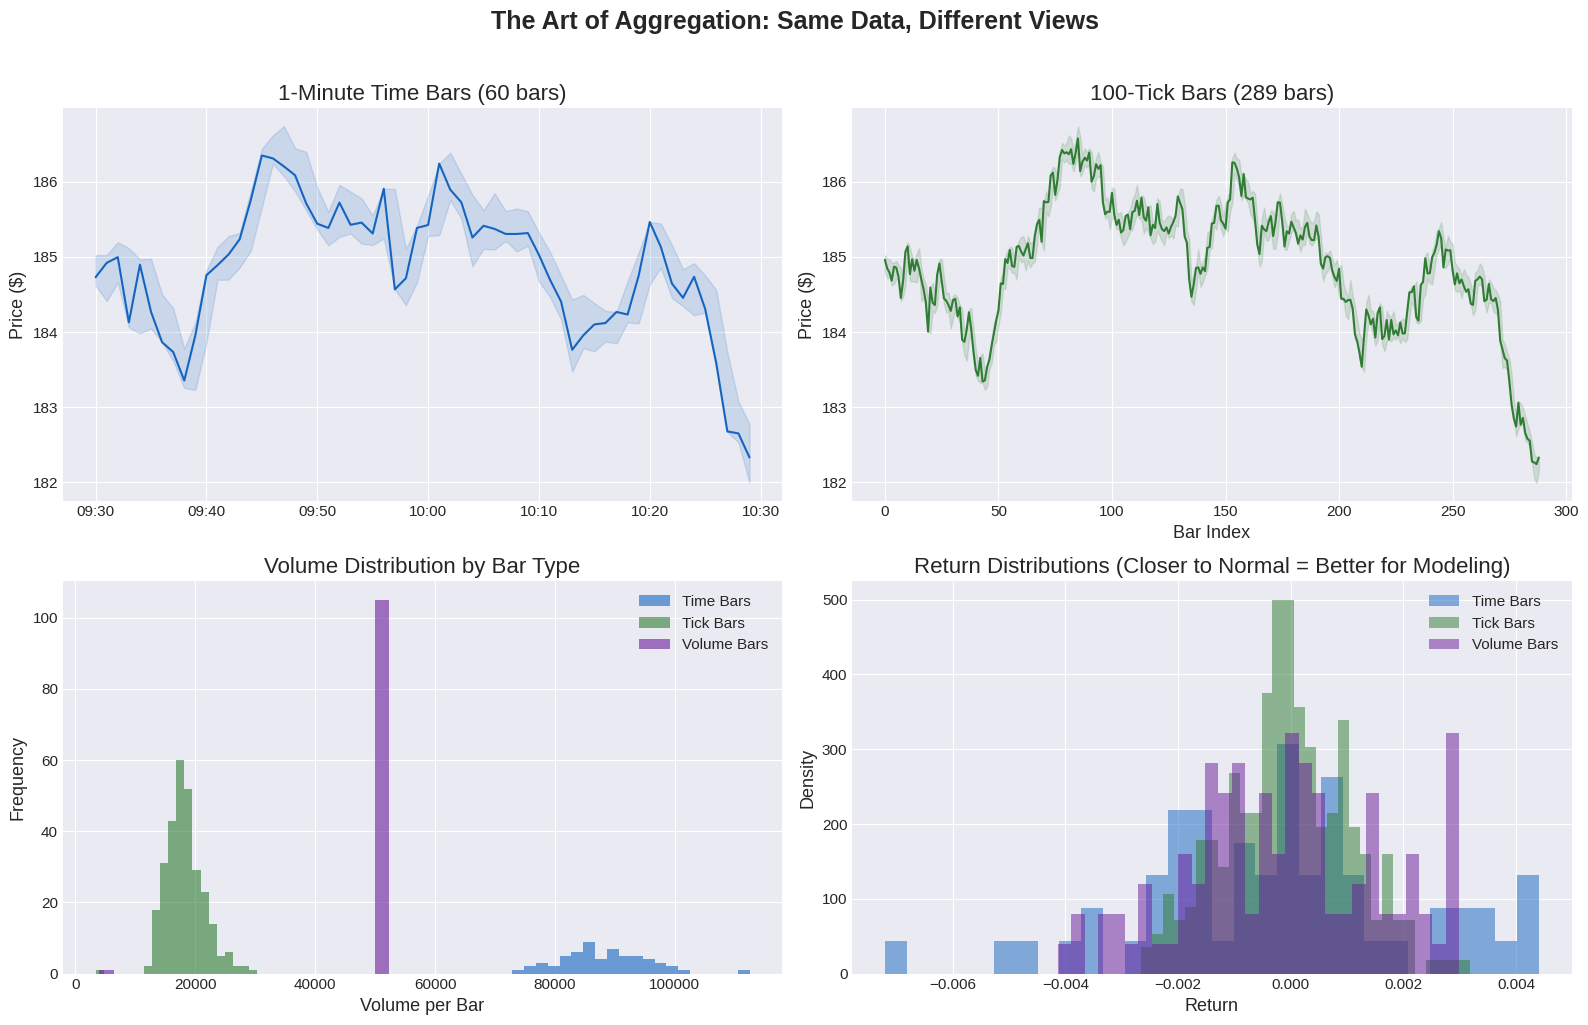


STATISTICAL PROPERTIES OF RETURNS BY BAR TYPE
Bar Type                  N         Mean          Std       Skew   Kurtosis   JB p-val
----------------------------------------------------------------------------------
1-Min Time Bars          59    -0.000219     0.002388    -0.1566     0.2425     0.8246
100-Tick Bars           288    -0.000049     0.001085     0.0878    -0.1370     0.7425
Volume Bars             105    -0.000126     0.001731    -0.0523    -0.6084     0.4345

💡 Higher Jarque-Bera p-value → closer to Gaussian → better for many ML models


In [4]:
# ========================================
# Market Data Types: Generation & Analysis
# ========================================

class TickType(Enum):
    TRADE = "trade"
    QUOTE = "quote"
    ORDER = "order"


@dataclass
class TradeTick:
    """Atomic unit of market data: a single executed trade."""
    timestamp: datetime
    symbol: str
    price: float
    volume: int
    aggressor_side: str  # 'buy' or 'sell'
    exchange: str = "XNAS"
    trade_id: int = 0


@dataclass
class QuoteTick:
    """National Best Bid and Offer snapshot."""
    timestamp: datetime
    symbol: str
    bid_price: float
    bid_size: int
    ask_price: float
    ask_size: int
    exchange: str = "XNAS"

    @property
    def mid_price(self) -> float:
        return (self.bid_price + self.ask_price) / 2

    @property
    def spread(self) -> float:
        return self.ask_price - self.bid_price

    @property
    def spread_bps(self) -> float:
        return (self.spread / self.mid_price) * 10_000


@dataclass
class OHLCVBar:
    """Aggregated bar from tick data."""
    timestamp: datetime
    symbol: str
    open: float
    high: float
    low: float
    close: float
    volume: int
    num_trades: int
    vwap: float


class TickGenerator:
    """Simulates realistic tick-level market data using geometric Brownian motion
    with Poisson-distributed trade arrivals."""

    def __init__(self, symbol: str, initial_price: float = 100.0,
                 volatility: float = 0.20, avg_trades_per_second: float = 5.0,
                 avg_spread_bps: float = 5.0, seed: int = 42):
        self.symbol = symbol
        self.price = initial_price
        self.volatility = volatility
        self.avg_trades_per_second = avg_trades_per_second
        self.avg_spread_bps = avg_spread_bps
        self.rng = np.random.RandomState(seed)

    def generate_ticks(self, start_time: datetime, duration_seconds: int) -> List[TradeTick]:
        """Generate trade ticks over a time window."""
        ticks = []
        current_time = start_time
        end_time = start_time + timedelta(seconds=duration_seconds)
        dt = 1.0 / (252 * 6.5 * 3600)  # fraction of a trading year per second
        trade_id = 0

        while current_time < end_time:
            inter_arrival = self.rng.exponential(1.0 / self.avg_trades_per_second)
            current_time += timedelta(seconds=inter_arrival)
            if current_time >= end_time:
                break

            drift = 0.0
            shock = self.rng.normal(0, 1)
            self.price *= np.exp((drift - 0.5 * self.volatility**2) * dt +
                                 self.volatility * np.sqrt(dt) * shock)

            spread = self.price * self.avg_spread_bps / 10_000
            side = 'buy' if self.rng.random() > 0.5 else 'sell'
            trade_price = self.price + (spread / 2 if side == 'buy' else -spread / 2)

            volume = int(self.rng.lognormal(mean=4.5, sigma=1.2))
            volume = max(1, min(volume, 10000))

            ticks.append(TradeTick(
                timestamp=current_time,
                symbol=self.symbol,
                price=round(trade_price, 4),
                volume=volume,
                aggressor_side=side,
                trade_id=trade_id
            ))
            trade_id += 1

        return ticks


class BarAggregator:
    """Aggregates tick data into various bar types, demonstrating the information
    trade-off between resolution and tractability."""

    @staticmethod
    def time_bars(ticks: List[TradeTick], interval_seconds: int) -> List[OHLCVBar]:
        """Aggregate ticks into fixed-time OHLCV bars."""
        if not ticks:
            return []

        bars = []
        interval = timedelta(seconds=interval_seconds)
        bar_start = ticks[0].timestamp.replace(microsecond=0)
        bar_ticks: List[TradeTick] = []

        for tick in ticks:
            if tick.timestamp >= bar_start + interval:
                if bar_ticks:
                    bars.append(BarAggregator._make_bar(bar_ticks, bar_start))
                bar_start = bar_start + interval
                while tick.timestamp >= bar_start + interval:
                    bar_start += interval
                bar_ticks = []
            bar_ticks.append(tick)

        if bar_ticks:
            bars.append(BarAggregator._make_bar(bar_ticks, bar_start))

        return bars

    @staticmethod
    def tick_bars(ticks: List[TradeTick], ticks_per_bar: int) -> List[OHLCVBar]:
        """Aggregate every N ticks into a bar."""
        bars = []
        for i in range(0, len(ticks), ticks_per_bar):
            chunk = ticks[i:i + ticks_per_bar]
            if chunk:
                bars.append(BarAggregator._make_bar(chunk, chunk[0].timestamp))
        return bars

    @staticmethod
    def volume_bars(ticks: List[TradeTick], volume_per_bar: int) -> List[OHLCVBar]:
        """Aggregate ticks until cumulative volume reaches threshold."""
        bars = []
        chunk: List[TradeTick] = []
        cum_vol = 0

        for tick in ticks:
            chunk.append(tick)
            cum_vol += tick.volume
            if cum_vol >= volume_per_bar:
                bars.append(BarAggregator._make_bar(chunk, chunk[0].timestamp))
                chunk = []
                cum_vol = 0

        if chunk:
            bars.append(BarAggregator._make_bar(chunk, chunk[0].timestamp))
        return bars

    @staticmethod
    def dollar_bars(ticks: List[TradeTick], dollars_per_bar: float) -> List[OHLCVBar]:
        """Aggregate ticks until cumulative dollar volume reaches threshold."""
        bars = []
        chunk: List[TradeTick] = []
        cum_dollars = 0.0

        for tick in ticks:
            chunk.append(tick)
            cum_dollars += tick.price * tick.volume
            if cum_dollars >= dollars_per_bar:
                bars.append(BarAggregator._make_bar(chunk, chunk[0].timestamp))
                chunk = []
                cum_dollars = 0.0

        if chunk:
            bars.append(BarAggregator._make_bar(chunk, chunk[0].timestamp))
        return bars

    @staticmethod
    def _make_bar(ticks: List[TradeTick], bar_time: datetime) -> OHLCVBar:
        prices = [t.price for t in ticks]
        volumes = [t.volume for t in ticks]
        total_vol = sum(volumes)
        vwap = sum(p * v for p, v in zip(prices, volumes)) / total_vol if total_vol > 0 else prices[-1]

        return OHLCVBar(
            timestamp=bar_time,
            symbol=ticks[0].symbol,
            open=prices[0],
            high=max(prices),
            low=min(prices),
            close=prices[-1],
            volume=total_vol,
            num_trades=len(ticks),
            vwap=round(vwap, 4),
        )


# --- Generate tick data and demonstrate aggregation ---

generator = TickGenerator("AAPL", initial_price=185.0, volatility=0.25,
                          avg_trades_per_second=8.0, avg_spread_bps=3.0)
ticks = generator.generate_ticks(
    start_time=datetime(2025, 1, 15, 9, 30, 0),
    duration_seconds=3600  # 1 hour of trading
)

print("=" * 80)
print("TICK DATA GENERATION")
print("=" * 80)
print(f"Symbol: AAPL")
print(f"Duration: 1 hour (09:30 - 10:30)")
print(f"Total ticks generated: {len(ticks):,}")
print(f"Avg ticks/second: {len(ticks) / 3600:.1f}")
print(f"Price range: ${min(t.price for t in ticks):.2f} — ${max(t.price for t in ticks):.2f}")
print(f"Total volume: {sum(t.volume for t in ticks):,} shares")
print(f"Total dollar volume: ${sum(t.price * t.volume for t in ticks):,.0f}")

# Aggregate into different bar types
time_bars_1m = BarAggregator.time_bars(ticks, interval_seconds=60)
time_bars_5m = BarAggregator.time_bars(ticks, interval_seconds=300)
tick_bars_100 = BarAggregator.tick_bars(ticks, ticks_per_bar=100)
volume_bars = BarAggregator.volume_bars(ticks, volume_per_bar=50000)
dollar_bars = BarAggregator.dollar_bars(ticks, dollars_per_bar=10_000_000)

print(f"\n{'Bar Type':<20} {'Count':>8} {'Avg Trades/Bar':>16} {'Info Retained':>15}")
print("-" * 62)
bar_types = [
    ("Raw Ticks", len(ticks), 1, 1.0),
    ("1-min Time Bars", len(time_bars_1m), len(ticks)/max(len(time_bars_1m),1), 5/max(len(ticks)/max(len(time_bars_1m),1)*4,1)),
    ("5-min Time Bars", len(time_bars_5m), len(ticks)/max(len(time_bars_5m),1), 5/max(len(ticks)/max(len(time_bars_5m),1)*4,1)),
    ("100-Tick Bars", len(tick_bars_100), 100, 5/(100*4)),
    ("Volume Bars (50k)", len(volume_bars), len(ticks)/max(len(volume_bars),1), 5/max(len(ticks)/max(len(volume_bars),1)*4,1)),
    ("Dollar Bars ($10M)", len(dollar_bars), len(ticks)/max(len(dollar_bars),1), 5/max(len(ticks)/max(len(dollar_bars),1)*4,1)),
]
for name, count, avg_trades, info in bar_types:
    print(f"{name:<20} {count:>8,} {avg_trades:>16.1f} {info:>14.4f}")

print("\n💡 Lower 'Info Retained' = more compression = more information lost")

# --- Visualization: comparing bar types ---

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("The Art of Aggregation: Same Data, Different Views",
             fontsize=18, fontweight='bold', y=1.02)

# 1-minute time bars
ax = axes[0, 0]
bar_times = [b.timestamp for b in time_bars_1m]
bar_closes = [b.close for b in time_bars_1m]
bar_volumes = [b.volume for b in time_bars_1m]
ax.plot(bar_times, bar_closes, color=COLORS['tick'], linewidth=1.5)
ax.fill_between(bar_times, [b.low for b in time_bars_1m],
                [b.high for b in time_bars_1m], alpha=0.15, color=COLORS['tick'])
ax.set_title(f"1-Minute Time Bars ({len(time_bars_1m)} bars)")
ax.set_ylabel("Price ($)")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Tick bars
ax = axes[0, 1]
tb_closes = [b.close for b in tick_bars_100]
ax.plot(range(len(tb_closes)), tb_closes, color=COLORS['bar'], linewidth=1.5)
ax.fill_between(range(len(tick_bars_100)), [b.low for b in tick_bars_100],
                [b.high for b in tick_bars_100], alpha=0.15, color=COLORS['bar'])
ax.set_title(f"100-Tick Bars ({len(tick_bars_100)} bars)")
ax.set_ylabel("Price ($)")
ax.set_xlabel("Bar Index")

# Volume distribution across bar types
ax = axes[1, 0]
time_bar_vols = [b.volume for b in time_bars_1m]
tick_bar_vols = [b.volume for b in tick_bars_100]
vol_bar_vols = [b.volume for b in volume_bars]
ax.hist(time_bar_vols, bins=20, alpha=0.6, label='Time Bars', color=COLORS['tick'])
ax.hist(tick_bar_vols, bins=20, alpha=0.6, label='Tick Bars', color=COLORS['bar'])
ax.hist(vol_bar_vols, bins=20, alpha=0.6, label='Volume Bars', color=COLORS['volume'])
ax.set_title("Volume Distribution by Bar Type")
ax.set_xlabel("Volume per Bar")
ax.set_ylabel("Frequency")
ax.legend()

# Returns distribution comparison (normality)
ax = axes[1, 1]
time_returns = np.diff([b.close for b in time_bars_1m]) / np.array([b.close for b in time_bars_1m[:-1]])
tick_returns = np.diff([b.close for b in tick_bars_100]) / np.array([b.close for b in tick_bars_100[:-1]])
vol_returns = np.diff([b.close for b in volume_bars]) / np.array([b.close for b in volume_bars[:-1]])

for returns, label, color in [(time_returns, 'Time Bars', COLORS['tick']),
                               (tick_returns, 'Tick Bars', COLORS['bar']),
                               (vol_returns, 'Volume Bars', COLORS['volume'])]:
    if len(returns) > 5:
        ax.hist(returns, bins=30, alpha=0.5, label=label, color=color, density=True)

ax.set_title("Return Distributions (Closer to Normal = Better for Modeling)")
ax.set_xlabel("Return")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

# Statistical comparison of return distributions
print("\n" + "=" * 80)
print("STATISTICAL PROPERTIES OF RETURNS BY BAR TYPE")
print("=" * 80)
print(f"{'Bar Type':<20} {'N':>6} {'Mean':>12} {'Std':>12} {'Skew':>10} {'Kurtosis':>10} {'JB p-val':>10}")
print("-" * 82)

for returns, label in [(time_returns, '1-Min Time Bars'),
                        (tick_returns, '100-Tick Bars'),
                        (vol_returns, 'Volume Bars')]:
    if len(returns) > 8:
        jb_stat, jb_pval = stats.jarque_bera(returns)
        print(f"{label:<20} {len(returns):>6} {np.mean(returns):>12.6f} {np.std(returns):>12.6f} "
              f"{stats.skew(returns):>10.4f} {stats.kurtosis(returns):>10.4f} {jb_pval:>10.4f}")

print("\n💡 Higher Jarque-Bera p-value → closer to Gaussian → better for many ML models")

---

## 2. Data Vendors, APIs & Exchange Connectivity

### 2.1 The Data Vendor Landscape: A Map of the Territory

The market data industry is a stratified ecosystem where **price reflects latency and completeness**. At the top sit the institutional terminals—Bloomberg and Refinitiv (formerly Thomson Reuters)—offering real-time data across every asset class, deep historical archives, analytics, news, and messaging, all for $20,000-$25,000 per user per year. These are the instruments of professional finance, and their dominance rests not just on data quality but on **network effects**: everyone uses Bloomberg because everyone uses Bloomberg. Below them, a growing layer of API-first providers—Polygon.io, Alpha Vantage, IEX Cloud, Quandl (now Nasdaq Data Link)—offers programmatic access at a fraction of the cost, democratizing data access for independent quants and small firms.

The choice of data vendor is a strategic decision that shapes your research capability:

| Tier | Examples | Latency | Coverage | Cost | Best For |
|------|----------|---------|----------|------|----------|
| **Institutional** | Bloomberg, Refinitiv | Real-time | Global, all assets | $20k+/yr | Hedge funds, banks |
| **Professional API** | Polygon, IEX Cloud | Near real-time | US equities, some global | $100-500/mo | Quant researchers |
| **Free/Freemium** | Yahoo Finance, Alpha Vantage | Delayed/EOD | Limited | Free | Students, prototyping |
| **Exchange Direct** | NYSE, CME, NASDAQ | Ultra-low | Single exchange | Varies | HFT, market makers |
| **Alternative** | Quandl, Sentifi, Orbital | Varies | Specialized | Varies | Alpha research |

### 2.2 Exchange Connectivity Protocols: The Languages of Machines

When your algorithm communicates with an exchange or data provider, it speaks one of several protocols, each designed for a different set of constraints.

**REST (Representational State Transfer)** is the workhorse of web APIs. It follows a request-response pattern: your client sends an HTTP request, the server responds with data. REST is stateless, cacheable, and universally supported. Its simplicity makes it the default choice for historical data retrieval, account management, and low-frequency trading. But REST has a fundamental limitation: it is **pull-based**. You must ask for data; the server never pushes. This makes it unsuitable for real-time streaming, where every millisecond of latency matters.

**WebSocket** solves the push problem. After an initial HTTP handshake, WebSocket establishes a persistent, full-duplex connection where both client and server can send messages at any time. This is the protocol of choice for real-time market data feeds and live order updates. WebSocket connections are lightweight—far more efficient than polling a REST endpoint every 100 milliseconds—and provide the low-latency, event-driven delivery that trading systems require.

**FIX (Financial Information eXchange)** is the lingua franca of institutional trading. Developed in 1992, FIX is a session-oriented protocol designed specifically for order routing, execution reporting, and market data distribution between brokers, exchanges, and buy-side firms. A FIX message is a sequence of tag-value pairs (e.g., `35=D` for a new order, `55=AAPL` for the symbol, `44=185.50` for the price). FIX is battle-tested, standardized, and deeply embedded in the infrastructure of global finance. It is verbose and complex compared to REST or WebSocket, but its specificity is its strength—every field, every message type, every error condition is defined by the standard.

### Protocol Comparison: The Tradeoffs

| Protocol | Pattern | Latency | Complexity | Use Case |
|----------|---------|---------|------------|----------|
| **REST** | Request-Response | Medium (50-500ms) | Low | Historical data, account ops |
| **WebSocket** | Push/Bidirectional | Low (1-50ms) | Medium | Real-time feeds, live updates |
| **FIX** | Session-based | Very Low (<1ms) | High | Order routing, institutional |

The latency numbers above are approximate and depend on network topology, server load, and geographic distance. A REST call from New York to a server in New Jersey might take 5ms; the same call from Tokyo might take 200ms. For a high-frequency strategy, the difference is existential. For a daily rebalancing strategy, it is irrelevant. **Choose your protocol to match your strategy's timescale**, not your ambition.

---

### The Data Pipeline: From Wire to Model

Raw market data does not arrive in the format your models want. Between the exchange's matching engine and your research notebook lies a **data pipeline**—a sequence of transformations that normalizes, validates, enriches, and stores data. A well-designed pipeline is invisible; a poorly designed one is a source of endless bugs and silent errors.

$$\text{Exchange} \xrightarrow{\text{Protocol}} \text{Ingestion} \xrightarrow{\text{Validation}} \text{Normalization} \xrightarrow{\text{Enrichment}} \text{Storage} \xrightarrow{\text{Query}} \text{Model}$$

Each stage has its own concerns:

- **Ingestion**: Connecting to feeds, handling reconnection, managing rate limits
- **Validation**: Detecting bad ticks, price spikes, stale data, missing fields
- **Normalization**: Adjusting for splits, dividends, currency; aligning timestamps to UTC
- **Enrichment**: Adding derived fields (returns, VWAP, spread), joining with reference data
- **Storage**: Writing to databases with appropriate indexing and partitioning
- **Query**: Serving data to models with point-in-time correctness

PROTOCOL LATENCY COMPARISON
Protocol      Median (ms)     P95 (ms)     P99 (ms)     Max (ms)   Failures
------------------------------------------------------------------------
REST              120.611      358.966      565.253      800.000         10
WebSocket           8.092       94.146      100.000      100.000         10
FIX                 0.301        0.897        1.413        2.000         10


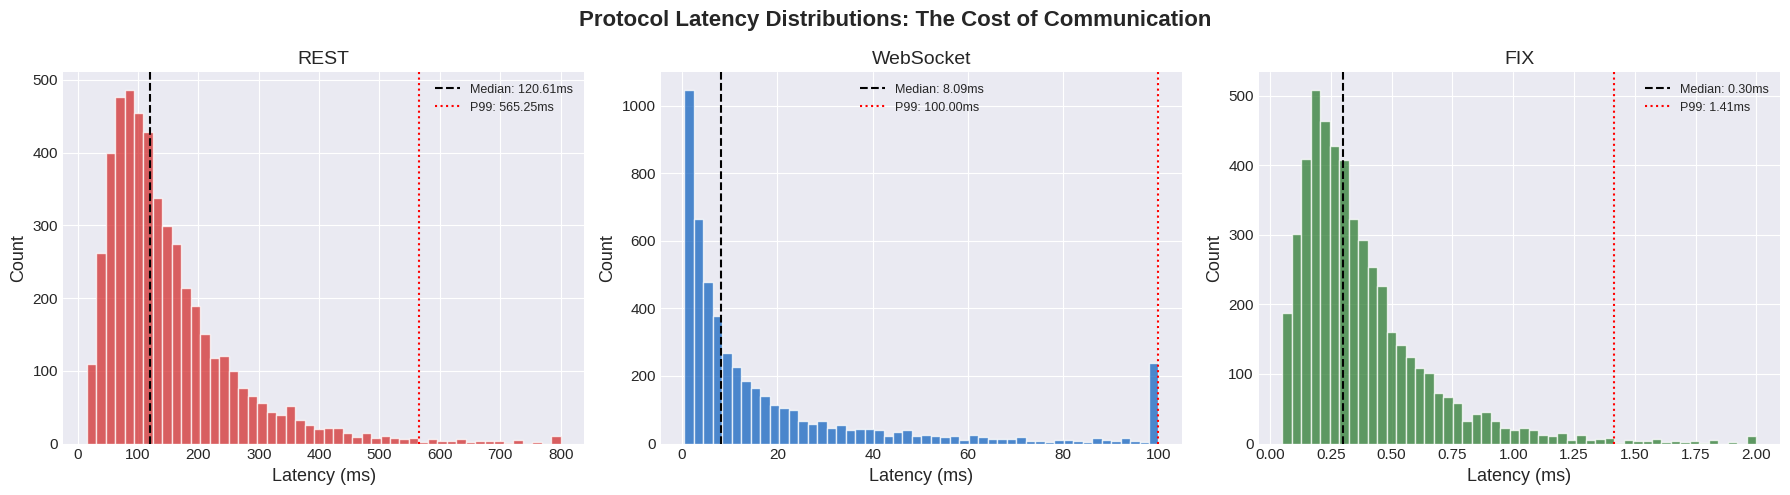


DATA PIPELINE RESULTS
Total ticks ingested:     28,828
Ticks accepted:           28,813
Ticks rejected:               15
Rejection rate:            0.05%

Rejection breakdown:
  AAPL — price_spike: 15

Clean dataset shape: (28813, 10)

Enriched columns: ['symbol', 'price', 'volume', 'side', 'exchange', 'dollar_volume', 'return', 'cum_volume', 'vwap', 'log_return']

Sample output:
                           symbol     price  volume  side exchange  dollar_volume    return  cum_volume        vwap  log_return
timestamp                                                                                                                      
2025-01-15 09:30:00.058659   AAPL  184.9511     131  sell     XNAS     24228.5941       NaN         131  184.951100         NaN
2025-01-15 09:30:00.066139   AAPL  185.0119     302   buy     XNAS     55873.5938  0.000329         433  184.993506    0.000329
2025-01-15 09:30:00.068739   AAPL  184.9453      47  sell     XNAS      8692.4291 -0.000360         480 

In [5]:
# ========================================
# API Simulation & Data Pipeline Design
# ========================================

class Protocol(Enum):
    REST = "REST"
    WEBSOCKET = "WebSocket"
    FIX = "FIX"


class APISimulator:
    """Simulates the behavior and latency characteristics of different
    market data protocols."""

    LATENCY_PROFILES = {
        Protocol.REST: {'mean_ms': 120, 'std_ms': 80, 'min_ms': 15, 'max_ms': 800},
        Protocol.WEBSOCKET: {'mean_ms': 8, 'std_ms': 12, 'min_ms': 0.5, 'max_ms': 100},
        Protocol.FIX: {'mean_ms': 0.3, 'std_ms': 0.2, 'min_ms': 0.05, 'max_ms': 2},
    }

    def __init__(self, protocol: Protocol, rng: np.random.RandomState = None):
        self.protocol = protocol
        self.profile = self.LATENCY_PROFILES[protocol]
        self.rng = rng or np.random.RandomState(42)
        self.request_count = 0
        self.total_latency_ms = 0

    def simulate_request(self, payload_size_bytes: int = 1024) -> Dict:
        """Simulate a single data request with realistic latency."""
        latency = max(
            self.profile['min_ms'],
            min(self.profile['max_ms'],
                self.rng.lognormal(
                    mean=np.log(self.profile['mean_ms']),
                    sigma=self.profile['std_ms'] / self.profile['mean_ms']
                ))
        )
        self.request_count += 1
        self.total_latency_ms += latency

        return {
            'protocol': self.protocol.value,
            'latency_ms': round(latency, 3),
            'payload_bytes': payload_size_bytes,
            'throughput_mbps': round(payload_size_bytes * 8 / (latency * 1000), 2),
            'success': self.rng.random() > 0.001,  # 99.9% success rate
        }

    def simulate_session(self, num_requests: int) -> pd.DataFrame:
        """Simulate a session of multiple requests."""
        results = [self.simulate_request() for _ in range(num_requests)]
        return pd.DataFrame(results)


# Simulate sessions for each protocol
n_requests = 5000
rng = np.random.RandomState(42)
protocols = {p: APISimulator(p, np.random.RandomState(42)) for p in Protocol}
sessions = {p.value: sim.simulate_session(n_requests) for p, sim in protocols.items()}

print("=" * 80)
print("PROTOCOL LATENCY COMPARISON")
print("=" * 80)
print(f"{'Protocol':<12} {'Median (ms)':>12} {'P95 (ms)':>12} {'P99 (ms)':>12} {'Max (ms)':>12} {'Failures':>10}")
print("-" * 72)

for proto_name, df in sessions.items():
    latencies = df['latency_ms']
    failures = (~df['success']).sum()
    print(f"{proto_name:<12} {latencies.median():>12.3f} {latencies.quantile(0.95):>12.3f} "
          f"{latencies.quantile(0.99):>12.3f} {latencies.max():>12.3f} {failures:>10}")

# Visualization: latency distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Protocol Latency Distributions: The Cost of Communication",
             fontsize=16, fontweight='bold')

colors_proto = {'REST': COLORS['latency'], 'WebSocket': COLORS['tick'], 'FIX': COLORS['bar']}

for ax, (proto_name, df) in zip(axes, sessions.items()):
    latencies = df['latency_ms']
    ax.hist(latencies, bins=50, color=colors_proto[proto_name], alpha=0.75, edgecolor='white')
    ax.axvline(latencies.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {latencies.median():.2f}ms')
    ax.axvline(latencies.quantile(0.99), color='red', linestyle=':', linewidth=1.5,
               label=f'P99: {latencies.quantile(0.99):.2f}ms')
    ax.set_title(f"{proto_name}", fontsize=14)
    ax.set_xlabel("Latency (ms)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


# ========================================
# Data Pipeline Implementation
# ========================================

class DataQualityFlag(Enum):
    VALID = "valid"
    STALE = "stale"
    SPIKE = "price_spike"
    MISSING = "missing_field"
    DUPLICATE = "duplicate"
    OUT_OF_HOURS = "out_of_hours"


class DataValidator:
    """Validates incoming tick data for common anomalies. In production, bad data
    that passes validation is indistinguishable from a real signal—a silent source
    of catastrophic losses."""

    def __init__(self, max_price_change_pct: float = 10.0,
                 max_staleness_seconds: float = 30.0):
        self.max_price_change_pct = max_price_change_pct
        self.max_staleness_seconds = max_staleness_seconds
        self.last_price: Dict[str, float] = {}
        self.last_timestamp: Dict[str, datetime] = {}
        self.stats = defaultdict(lambda: defaultdict(int))

    def validate(self, tick: TradeTick) -> Tuple[bool, DataQualityFlag]:
        """Returns (is_valid, flag) for a single tick."""
        symbol = tick.symbol

        if tick.price <= 0 or tick.volume <= 0:
            self.stats[symbol][DataQualityFlag.MISSING] += 1
            return False, DataQualityFlag.MISSING

        if symbol in self.last_price:
            pct_change = abs(tick.price - self.last_price[symbol]) / self.last_price[symbol] * 100
            if pct_change > self.max_price_change_pct:
                self.stats[symbol][DataQualityFlag.SPIKE] += 1
                return False, DataQualityFlag.SPIKE

        if symbol in self.last_timestamp:
            staleness = (tick.timestamp - self.last_timestamp[symbol]).total_seconds()
            if staleness > self.max_staleness_seconds:
                self.stats[symbol][DataQualityFlag.STALE] += 1

            if staleness == 0 and tick.price == self.last_price.get(symbol):
                self.stats[symbol][DataQualityFlag.DUPLICATE] += 1
                return False, DataQualityFlag.DUPLICATE

        self.last_price[symbol] = tick.price
        self.last_timestamp[symbol] = tick.timestamp
        self.stats[symbol][DataQualityFlag.VALID] += 1
        return True, DataQualityFlag.VALID


class CorporateActionAdjuster:
    """Adjusts historical prices for stock splits and dividends.
    Unadjusted data is the most common source of phantom signals
    in naive backtests."""

    @staticmethod
    def adjust_for_split(prices: pd.Series, split_date: str,
                         split_ratio: float) -> pd.Series:
        """Apply split adjustment: multiply pre-split prices by 1/ratio."""
        adjusted = prices.copy()
        mask = adjusted.index < split_date
        adjusted[mask] = adjusted[mask] / split_ratio
        return adjusted

    @staticmethod
    def adjust_for_dividend(prices: pd.Series, ex_date: str,
                            dividend: float) -> pd.Series:
        """Apply dividend adjustment: reduce pre-ex-date prices by dividend amount."""
        adjusted = prices.copy()
        mask = adjusted.index < ex_date
        factor = 1 - dividend / adjusted[adjusted.index >= ex_date].iloc[0]
        adjusted[mask] = adjusted[mask] * factor
        return adjusted


class DataPipeline:
    """End-to-end pipeline: ingest → validate → normalize → enrich → output."""

    def __init__(self, validator: DataValidator):
        self.validator = validator
        self.processed = 0
        self.rejected = 0

    def process(self, ticks: List[TradeTick]) -> pd.DataFrame:
        """Process raw ticks through the full pipeline."""
        valid_ticks = []
        for tick in ticks:
            is_valid, flag = self.validator.validate(tick)
            self.processed += 1
            if is_valid:
                valid_ticks.append(tick)
            else:
                self.rejected += 1

        df = pd.DataFrame([
            {'timestamp': t.timestamp, 'symbol': t.symbol, 'price': t.price,
             'volume': t.volume, 'side': t.aggressor_side, 'exchange': t.exchange}
            for t in valid_ticks
        ])

        if df.empty:
            return df

        df = df.set_index('timestamp').sort_index()
        df['dollar_volume'] = df['price'] * df['volume']
        df['return'] = df['price'].pct_change()
        df['cum_volume'] = df['volume'].cumsum()
        df['vwap'] = df['dollar_volume'].cumsum() / df['cum_volume']
        df['log_return'] = np.log(df['price'] / df['price'].shift(1))

        return df


# --- Run the pipeline on our generated ticks ---

# Inject some bad ticks to demonstrate validation
bad_ticks = ticks.copy()
rng_bad = np.random.RandomState(99)
for i in rng_bad.choice(len(bad_ticks), size=15, replace=False):
    bad_ticks[i] = TradeTick(
        timestamp=bad_ticks[i].timestamp,
        symbol="AAPL",
        price=bad_ticks[i].price * (1 + rng_bad.choice([-1, 1]) * 0.15),
        volume=bad_ticks[i].volume,
        aggressor_side=bad_ticks[i].aggressor_side,
        trade_id=bad_ticks[i].trade_id,
    )

validator = DataValidator(max_price_change_pct=5.0, max_staleness_seconds=10.0)
pipeline = DataPipeline(validator)
clean_df = pipeline.process(bad_ticks)

print("\n" + "=" * 80)
print("DATA PIPELINE RESULTS")
print("=" * 80)
print(f"Total ticks ingested:   {pipeline.processed:>8,}")
print(f"Ticks accepted:         {pipeline.processed - pipeline.rejected:>8,}")
print(f"Ticks rejected:         {pipeline.rejected:>8,}")
print(f"Rejection rate:         {pipeline.rejected/pipeline.processed*100:>7.2f}%")

print("\nRejection breakdown:")
for symbol, flags in validator.stats.items():
    for flag, count in flags.items():
        if flag != DataQualityFlag.VALID:
            print(f"  {symbol} — {flag.value}: {count}")

print(f"\nClean dataset shape: {clean_df.shape}")
print(f"\nEnriched columns: {list(clean_df.columns)}")
print(f"\nSample output:")
print(clean_df.head(10).to_string())

---

## 3. Data Storage & Database Design

### 3.1 The Architecture of Financial Memory

Where you store your data determines how quickly you can retrieve it, how flexibly you can query it, and ultimately what questions you can afford to ask. The history of financial databases mirrors the evolution of finance itself: from flat files and spreadsheets in the early days, to relational databases as strategies grew more systematic, to specialized time-series databases as the volume of market data overwhelmed general-purpose storage.

The choice of database is a decision about **access patterns**. Ask yourself: Will you mostly query by time range ("give me all AAPL ticks between 9:30 and 10:00 on Jan 15")? By symbol ("give me the daily close for all S&P 500 stocks on Jan 15")? By condition ("give me all days where AAPL volume exceeded 2x its 20-day average")? Each access pattern favors a different storage architecture.

### 3.2 Database Architectures for Market Data

**Relational Databases (PostgreSQL, MySQL)** remain the backbone of most financial data infrastructure. Their strengths are maturity, ACID compliance, and the expressive power of SQL. For fundamental data, reference data, and moderate-frequency bar data, PostgreSQL is an excellent choice. Its table-based schema enforces data integrity, and its query optimizer handles complex joins efficiently. The weakness of relational databases is **write throughput** at tick-data scale—ingesting millions of rows per second pushes PostgreSQL to its limits.

**Time-Series Databases (TimescaleDB, InfluxDB, QuestDB, kdb+)** are purpose-built for the access patterns of market data. They optimize for time-range queries, high ingestion rates, and columnar compression. TimescaleDB extends PostgreSQL with hypertables that automatically partition data by time, achieving 10-100x better performance for time-range queries while retaining full SQL compatibility. At the extreme end, **kdb+** (used by most major banks and hedge funds) stores data in columnar format with a vector-oriented query language (q) that can scan billions of ticks in seconds. kdb+ is the gold standard, but its licensing cost reflects its clientele.

**Object Storage + Parquet (S3, GCS + Apache Parquet)** is increasingly popular for large-scale backtesting datasets. Parquet files are columnar, compressed, and partitioned—you can store petabytes of tick data for pennies per gigabyte on cloud object storage. The trade-off is query flexibility: you cannot run ad-hoc SQL queries against Parquet files as easily as against a database. Tools like DuckDB and Apache Spark bridge this gap, offering SQL-like querying over Parquet files.

### 3.3 Schema Design Principles

A well-designed schema is an act of future-proofing. The questions you'll want to ask in six months are not the questions you're asking today. Key principles:

1. **Separate raw from derived data**: Never overwrite raw market data. Store it immutably, and compute derived fields (returns, VWAP, adjusted prices) in separate tables or views.
2. **Partition by time**: All market data queries are time-bounded. Partitioning by day or month makes range queries fast and old data easy to archive.
3. **Index by symbol + time**: The two most common query patterns. A composite index on (symbol, timestamp) is almost always correct.
4. **Store adjustment factors, not adjusted prices**: When a stock splits, store the split ratio and date. Compute adjusted prices at query time. This preserves the raw data and allows different adjustment methodologies.
5. **Record metadata**: Capture when data was ingested, from which vendor, at what quality level. When something goes wrong—and it will—this audit trail is invaluable.

---

## 4. Real-Time Streaming & the Backtesting Data Warehouse

### 4.1 Streaming: Simulating the Live Experience

A backtest that works perfectly on static data can fail spectacularly when confronted with a live data stream. The difference is not just latency—it is the **temporal structure** of information arrival. In a backtest, you can look at the entire day's data at once. In live trading, you receive one tick at a time, and your system must react before the next tick arrives. Building a streaming simulation forces you to confront this reality: your model must make decisions with **incomplete information**, your pipeline must handle **out-of-order arrivals**, and your system must be **stateful** across ticks without leaking future information.

### 4.2 The Backtesting Data Warehouse

A backtesting data warehouse is more than a database—it is a **contract between your past and future self**. It guarantees that historical data is point-in-time correct, survivorship-bias-free, and adjusted consistently. The warehouse should answer two questions with absolute confidence:

1. *What did the world look like at time $t$?* (Point-in-time query)
2. *What universe of assets was tradeable at time $t$?* (Survivorship-free universe)

If your warehouse cannot answer these questions correctly, your backtests are fiction.

### 4.3 Data Integrity: The Silent Enemies

The most dangerous bugs in quantitative finance are not crashes or error messages—they are **silent corruptions** that produce plausible but wrong results. Three enemies stand above the rest:

**Survivorship Bias**: Your historical dataset only contains companies that exist today. Companies that went bankrupt, were acquired, or delisted have vanished from the data. This systematically inflates historical returns because you're only looking at winners. A momentum strategy backtested on the current S&P 500 constituents will look better than it should, because it never had to hold the stocks that were removed from the index after declining.

**Look-Ahead Bias**: Your model uses information that was not available at the time of the trading decision. This can be subtle: using the closing price to make a decision at the open, using revised GDP figures instead of initial releases, or using tomorrow's trading volume to filter today's universe. Look-ahead bias makes strategies look unrealistically profitable.

**Data Snooping Bias**: You test hundreds of strategies on the same dataset and report only the ones that work. By random chance, some will appear profitable. The more strategies you test, the more false discoveries you'll find. Proper defense requires out-of-sample testing, Bonferroni correction, or the deflated Sharpe ratio methodology.

In [6]:
# ========================================
# Data Storage: SQLite Data Warehouse Demo
# ========================================

class MarketDataWarehouse:
    """A lightweight backtesting data warehouse using SQLite.
    Demonstrates schema design, point-in-time queries, and
    corporate action handling."""

    def __init__(self, db_path: str = ":memory:"):
        self.conn = sqlite3.connect(db_path)
        self.conn.execute("PRAGMA journal_mode=WAL")
        self._create_schema()

    def _create_schema(self):
        """Create the warehouse schema with separate tables for
        raw data, adjustments, and metadata."""
        self.conn.executescript("""
            CREATE TABLE IF NOT EXISTS daily_bars (
                symbol      TEXT NOT NULL,
                date        TEXT NOT NULL,
                open        REAL NOT NULL,
                high        REAL NOT NULL,
                low         REAL NOT NULL,
                close       REAL NOT NULL,
                volume      INTEGER NOT NULL,
                source      TEXT DEFAULT 'simulation',
                ingested_at TEXT DEFAULT (datetime('now')),
                PRIMARY KEY (symbol, date)
            );

            CREATE TABLE IF NOT EXISTS corporate_actions (
                symbol      TEXT NOT NULL,
                date        TEXT NOT NULL,
                action_type TEXT NOT NULL,  -- 'split', 'dividend', 'delist'
                factor      REAL,           -- split ratio or dividend amount
                PRIMARY KEY (symbol, date, action_type)
            );

            CREATE TABLE IF NOT EXISTS universe (
                symbol      TEXT NOT NULL,
                index_name  TEXT NOT NULL,
                added_date  TEXT NOT NULL,
                removed_date TEXT,           -- NULL if still active
                PRIMARY KEY (symbol, index_name, added_date)
            );

            CREATE TABLE IF NOT EXISTS fundamentals (
                symbol          TEXT NOT NULL,
                report_date     TEXT NOT NULL,   -- when data became available
                period_end      TEXT NOT NULL,   -- fiscal period it covers
                eps             REAL,
                revenue         REAL,
                net_income      REAL,
                book_value      REAL,
                PRIMARY KEY (symbol, report_date, period_end)
            );

            CREATE INDEX IF NOT EXISTS idx_bars_date ON daily_bars(date);
            CREATE INDEX IF NOT EXISTS idx_bars_symbol ON daily_bars(symbol);
            CREATE INDEX IF NOT EXISTS idx_universe_dates ON universe(added_date, removed_date);
        """)

    def ingest_bars(self, bars_df: pd.DataFrame):
        """Ingest a DataFrame of daily bars."""
        bars_df.to_sql('daily_bars', self.conn, if_exists='append', index=False)

    def query_point_in_time(self, symbol: str, as_of_date: str) -> pd.DataFrame:
        """Point-in-time query: return data available on or before as_of_date."""
        query = """
            SELECT * FROM daily_bars
            WHERE symbol = ? AND date <= ?
            ORDER BY date DESC
            LIMIT 252
        """
        return pd.read_sql(query, self.conn, params=(symbol, as_of_date))

    def query_universe(self, index_name: str, as_of_date: str) -> List[str]:
        """Survivorship-bias-free universe query: which symbols were in the
        index on a given date?"""
        query = """
            SELECT symbol FROM universe
            WHERE index_name = ?
              AND added_date <= ?
              AND (removed_date IS NULL OR removed_date > ?)
        """
        cursor = self.conn.execute(query, (index_name, as_of_date, as_of_date))
        return [row[0] for row in cursor.fetchall()]

    def query_cross_section(self, date: str) -> pd.DataFrame:
        """Cross-sectional query: all symbols on a given date."""
        query = "SELECT * FROM daily_bars WHERE date = ?"
        return pd.read_sql(query, self.conn, params=(date,))

    def close(self):
        self.conn.close()


# --- Populate the warehouse with simulated data ---

def generate_daily_bars(symbol: str, start_date: str, num_days: int,
                        initial_price: float, volatility: float,
                        rng: np.random.RandomState) -> pd.DataFrame:
    """Generate synthetic daily OHLCV bars."""
    dates = pd.bdate_range(start=start_date, periods=num_days)
    prices = [initial_price]
    for _ in range(num_days - 1):
        ret = rng.normal(0.0003, volatility / np.sqrt(252))
        prices.append(prices[-1] * np.exp(ret))

    rows = []
    for i, (date, close) in enumerate(zip(dates, prices)):
        daily_vol = volatility / np.sqrt(252)
        intraday_range = close * daily_vol * rng.uniform(0.8, 2.5)
        high = close + intraday_range * rng.uniform(0.3, 0.7)
        low = close - intraday_range * rng.uniform(0.3, 0.7)
        open_price = low + (high - low) * rng.uniform(0.2, 0.8)
        volume = int(rng.lognormal(mean=16, sigma=0.5))

        rows.append({
            'symbol': symbol,
            'date': date.strftime('%Y-%m-%d'),
            'open': round(open_price, 2),
            'high': round(max(high, open_price, close), 2),
            'low': round(min(low, open_price, close), 2),
            'close': round(close, 2),
            'volume': volume,
        })

    return pd.DataFrame(rows)


rng = np.random.RandomState(42)
warehouse = MarketDataWarehouse()

symbols_config = {
    'AAPL': (185.0, 0.25), 'MSFT': (375.0, 0.22), 'GOOGL': (140.0, 0.28),
    'AMZN': (155.0, 0.30), 'NVDA': (480.0, 0.45), 'META': (350.0, 0.35),
    'TSLA': (245.0, 0.50), 'JPM': (170.0, 0.18), 'JNJ': (155.0, 0.14),
    'XOM': (100.0, 0.22), 'DELISTED_CO': (45.0, 0.60),
}

all_bars = []
for symbol, (price, vol) in symbols_config.items():
    num_days = 504 if symbol != 'DELISTED_CO' else 252
    bars_df = generate_daily_bars(symbol, '2023-01-03', num_days, price, vol, rng)
    all_bars.append(bars_df)

combined = pd.concat(all_bars, ignore_index=True)
warehouse.ingest_bars(combined)

# Add universe membership (with a delisted company for survivorship bias demo)
universe_data = []
for sym in symbols_config:
    if sym == 'DELISTED_CO':
        universe_data.append((sym, 'SP500_SIM', '2020-01-01', '2023-09-15'))
    else:
        universe_data.append((sym, 'SP500_SIM', '2020-01-01', None))

warehouse.conn.executemany(
    "INSERT INTO universe VALUES (?, ?, ?, ?)", universe_data
)

# Add a corporate action (NVDA 10:1 split)
warehouse.conn.execute(
    "INSERT INTO corporate_actions VALUES (?, ?, ?, ?)",
    ('NVDA', '2024-06-10', 'split', 10.0)
)
warehouse.conn.commit()

print("=" * 80)
print("DATA WAREHOUSE POPULATED")
print("=" * 80)
print(f"Total bars stored: {len(combined):,}")
print(f"Symbols: {len(symbols_config)}")
print(f"Date range: {combined['date'].min()} to {combined['date'].max()}")

# --- Demonstrate point-in-time queries ---

print("\n" + "=" * 80)
print("POINT-IN-TIME QUERY DEMO")
print("=" * 80)

pit_data = warehouse.query_point_in_time('AAPL', '2023-06-30')
print(f"\nAAPL data as of 2023-06-30 (last 5 bars):")
print(pit_data.head().to_string(index=False))

# --- Demonstrate survivorship-bias-free universe ---

print("\n" + "=" * 80)
print("SURVIVORSHIP BIAS DEMONSTRATION")
print("=" * 80)

universe_before = warehouse.query_universe('SP500_SIM', '2023-06-01')
universe_after = warehouse.query_universe('SP500_SIM', '2024-01-01')

print(f"\nUniverse on 2023-06-01 ({len(universe_before)} symbols): {sorted(universe_before)}")
print(f"Universe on 2024-01-01 ({len(universe_after)} symbols):  {sorted(universe_after)}")
print(f"\n⚠️  DELISTED_CO was in the universe on 2023-06-01 but not on 2024-01-01.")
print(f"   A naive backtest using today's universe would never see DELISTED_CO,")
print(f"   systematically excluding its losses and inflating historical returns.")

DATA WAREHOUSE POPULATED
Total bars stored: 5,292
Symbols: 11
Date range: 2023-01-03 to 2024-12-06

POINT-IN-TIME QUERY DEMO

AAPL data as of 2023-06-30 (last 5 bars):
symbol       date   open   high    low  close   volume     source         ingested_at
  AAPL 2023-06-30 168.03 170.16 167.43 168.43  9435744 simulation 2026-03-21 02:15:44
  AAPL 2023-06-29 170.52 172.45 167.20 169.89  9056576 simulation 2026-03-21 02:15:44
  AAPL 2023-06-28 173.65 175.41 170.01 172.51 10985458 simulation 2026-03-21 02:15:44
  AAPL 2023-06-27 166.15 167.40 165.62 166.61  7570929 simulation 2026-03-21 02:15:44
  AAPL 2023-06-26 165.72 167.30 162.94 165.02  9808891 simulation 2026-03-21 02:15:44

SURVIVORSHIP BIAS DEMONSTRATION

Universe on 2023-06-01 (11 symbols): ['AAPL', 'AMZN', 'DELISTED_CO', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA', 'XOM']
Universe on 2024-01-01 (10 symbols):  ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'TSLA', 'XOM']

⚠️  DELISTED_CO was in the univer

---

## 5. Streaming Simulation & Comprehensive Pipeline

### 5.1 From Batch to Stream: A Change in Worldview

The transition from batch-processed historical data to live streaming data is not merely a technical upgrade—it is a **paradigm shift** in how your system relates to time. In batch mode, time is a column in a DataFrame, inert and controllable. In streaming mode, time is the medium in which your system exists, relentless and unforgiving. Every design decision changes: your model must be incremental (no looking back at the full history for each prediction), your state must be managed explicitly (what has the model seen so far?), and your error handling must be robust (what happens when a tick arrives out of order, or not at all?).

The streaming simulation below demonstrates these concerns in microcosm. We process ticks one at a time, maintaining running statistics, detecting regime changes, and producing signals—exactly as a live trading system would, but with the safety and reproducibility of simulation.

### 5.2 Putting It All Together

The final implementation brings together every concept from this module:

- **Tick generation** → simulated market data with realistic properties
- **Validation** → filtering bad data before it reaches your model
- **Aggregation** → converting ticks to bars of various types
- **Storage** → persisting clean data in a queryable warehouse
- **Streaming** → processing data in temporal order with incremental state
- **Analytics** → computing the statistics that inform trading decisions

This is the foundation upon which every subsequent module builds. Your strategies, your risk models, your execution algorithms—they all begin and end with data. The infrastructure you build here determines the ceiling of everything that follows.

REAL-TIME STREAMING SIMULATION RESULTS
Ticks processed: 28,828
Final VWAP: $184.8838
Final price: $182.3324
Max z-score: 3.852
Min z-score: -4.370
Final order flow imbalance: -0.0078


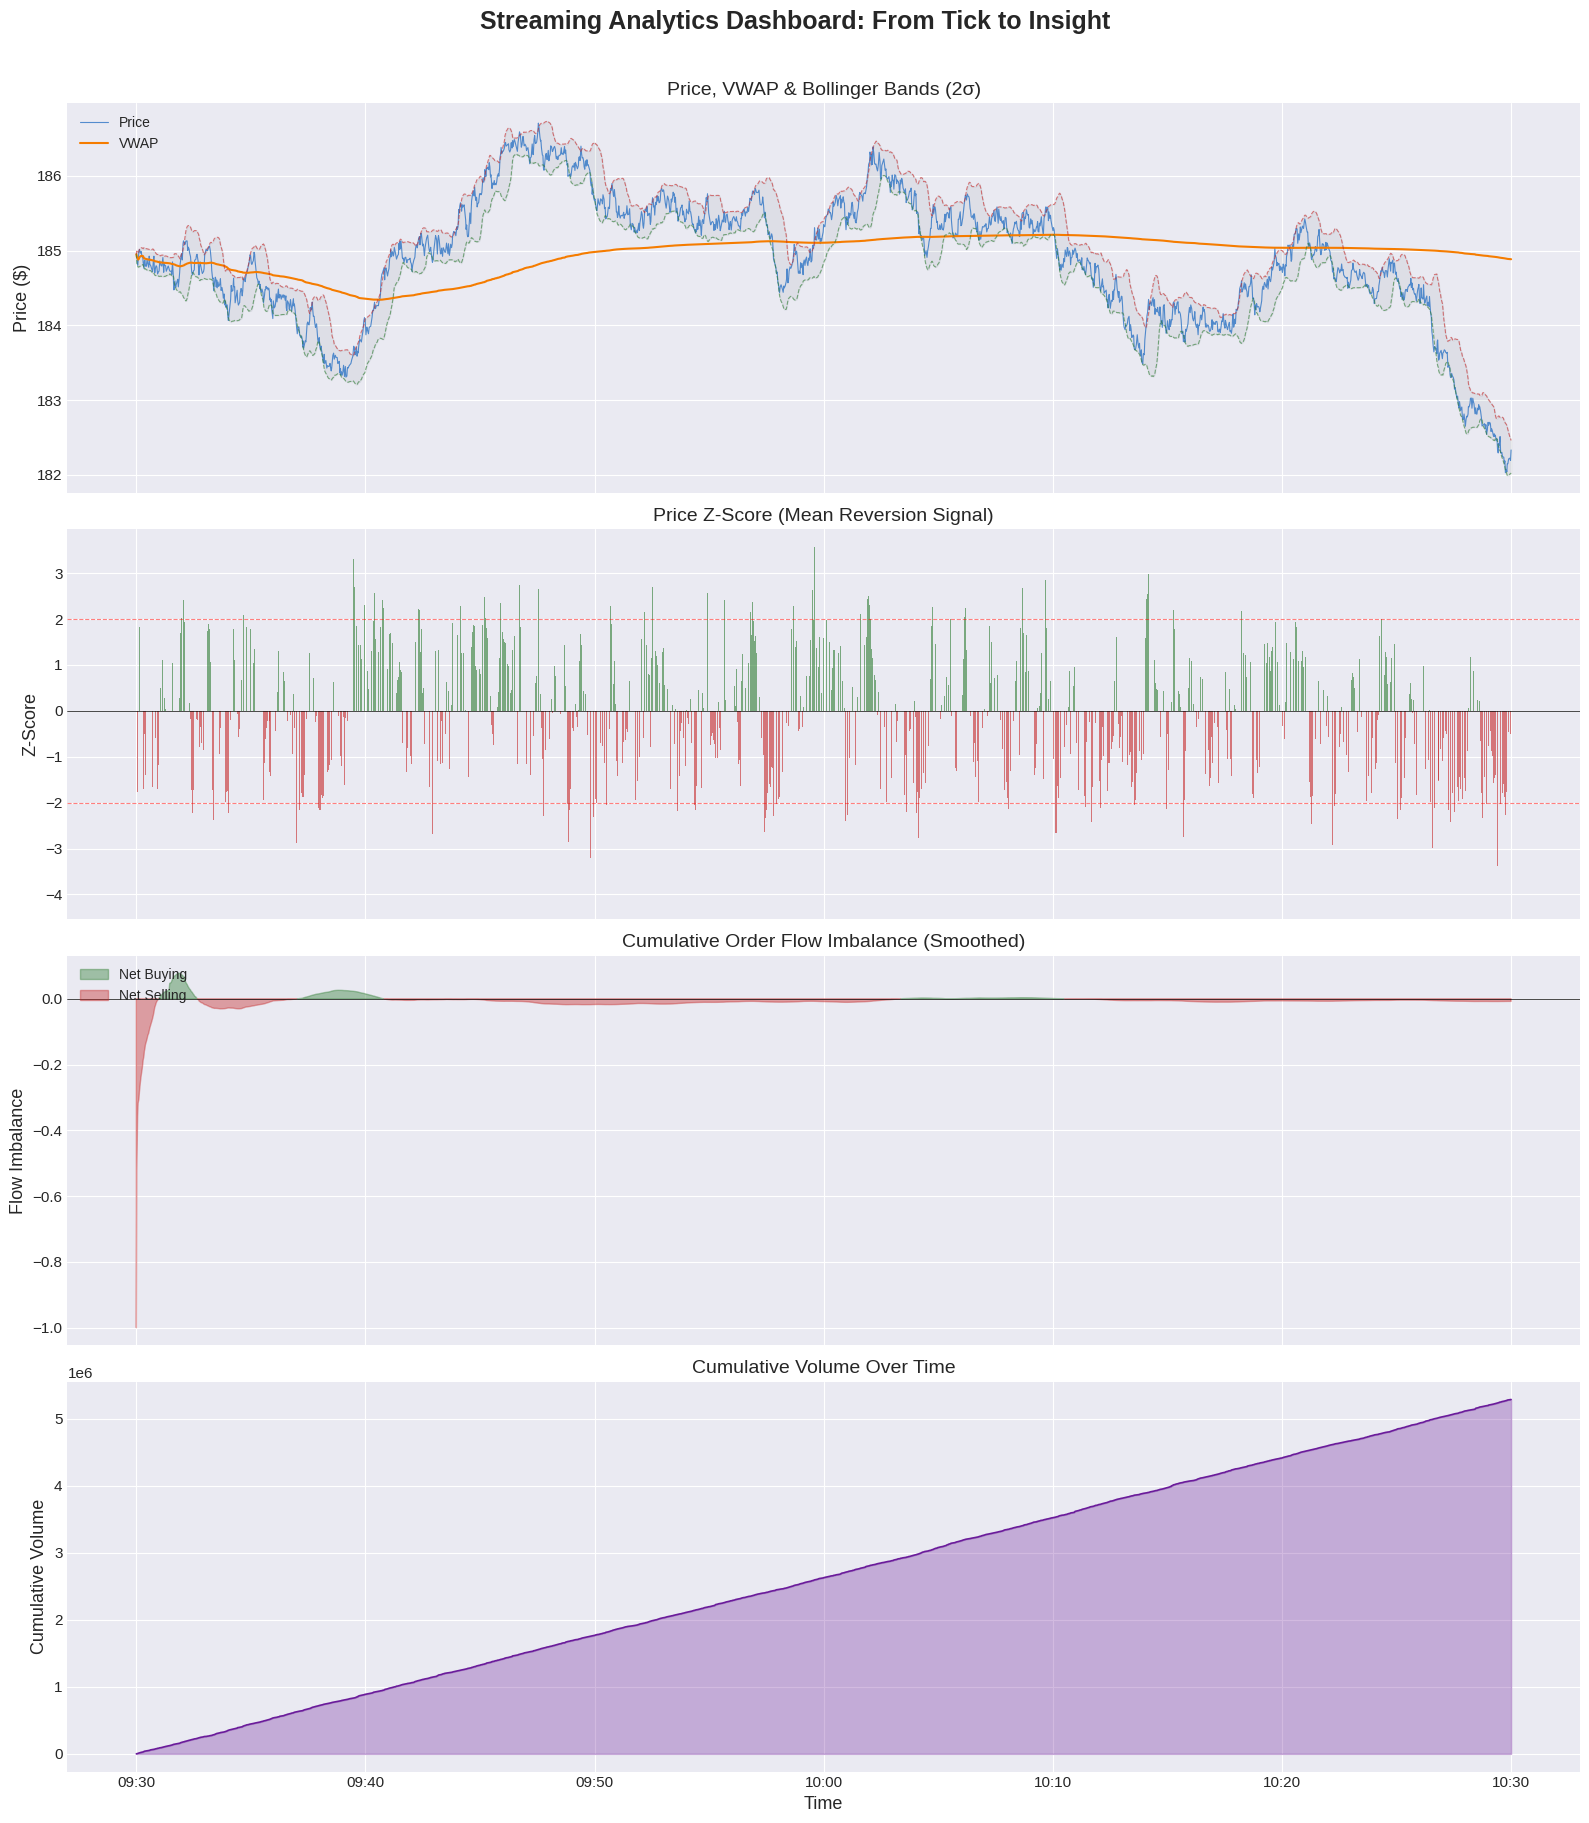


CROSS-SECTIONAL ANALYSIS FROM DATA WAREHOUSE

Symbol  Observations Ann. Return Ann. Vol  Sharpe Max DD   Skew  Kurtosis
  AAPL           251       19.9%    25.1%    0.79  31.1%  0.111    -0.085
  MSFT           251      -19.1%    22.6%   -0.85  24.5%  0.045     0.575
 GOOGL           251       22.2%    28.1%    0.79  25.3%  0.005     0.107
  AMZN           251       -9.8%    32.5%   -0.30  29.9%  0.002     0.561
  NVDA           251      -52.3%    44.1%   -1.19  49.6% -0.021    -0.221
  META           251       20.5%    34.4%    0.60  32.5%  0.212     0.596
  TSLA           251      109.7%    51.3%    2.14  65.6%  0.560     0.762
   JPM           251        7.3%    17.7%    0.41  19.3%  0.061     0.051
   JNJ           251       19.3%    14.2%    1.35  21.8%  0.083    -0.430
   XOM           251       -6.0%    19.4%   -0.31  27.4%  0.038    -0.363


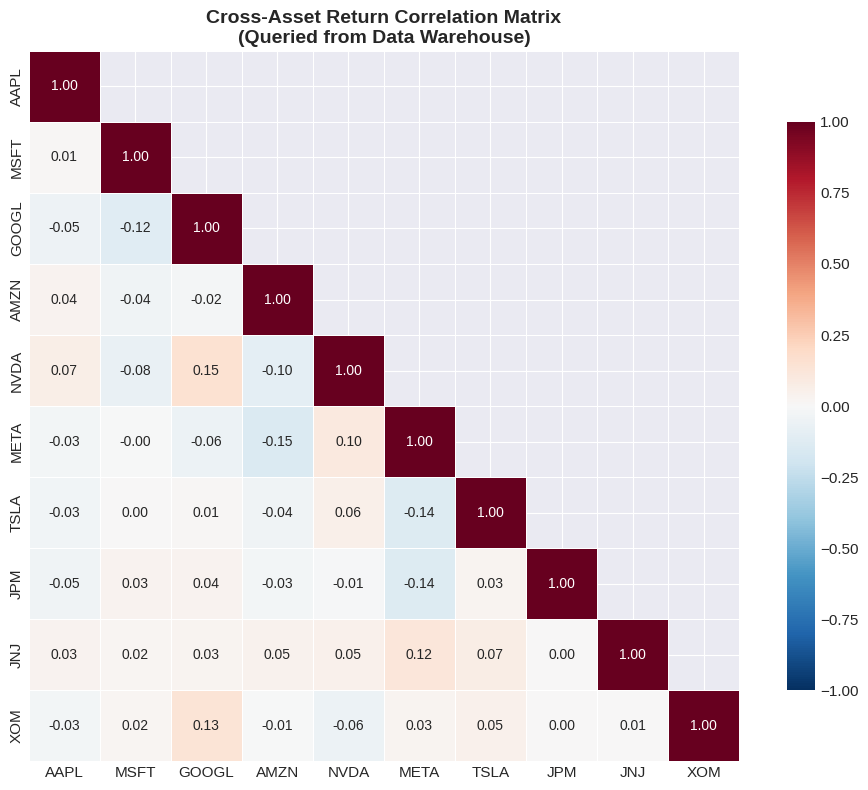


                      MODULE 2.3 — SUMMARY

Key Concepts Covered:

  1. MARKET DATA TAXONOMY
     • Tick data is the atomic unit; bars are lossy compressions
     • Volume/dollar bars often produce better statistical properties
     • Fundamental data requires point-in-time discipline

  2. PROTOCOLS & CONNECTIVITY
     • REST for historical data; WebSocket for real-time; FIX for institutional
     • Protocol choice must match strategy timescale
     • Latency distributions matter more than averages

  3. DATA PIPELINES
     • Validate before you trust: bad ticks destroy models silently
     • Normalize, enrich, and store in that order
     • Corporate actions must be handled or they become phantom signals

  4. STORAGE & WAREHOUSING
     • Schema design is an act of future-proofing
     • Point-in-time queries prevent look-ahead bias
     • Survivorship-bias-free universes are non-negotiable

  5. STREAMING
     • Live systems are stateful; backtests pretend they are not
     • Welfo

In [7]:
# ========================================
# Real-Time Streaming Simulation
# ========================================

class StreamingAnalytics:
    """Incremental analytics computed tick-by-tick, as in a live trading system.
    Uses Welford's algorithm for numerically stable online variance."""

    def __init__(self, window_size: int = 500):
        self.window_size = window_size
        self.prices = deque(maxlen=window_size)
        self.volumes = deque(maxlen=window_size)
        self.timestamps = deque(maxlen=window_size)

        # Welford's online algorithm state
        self.n = 0
        self.mean = 0.0
        self.M2 = 0.0

        # VWAP state
        self.cum_pv = 0.0
        self.cum_vol = 0

        # Trade flow state
        self.buy_volume = 0
        self.sell_volume = 0

    def update(self, tick: TradeTick) -> Dict[str, float]:
        """Process a single tick and return updated analytics."""
        self.prices.append(tick.price)
        self.volumes.append(tick.volume)
        self.timestamps.append(tick.timestamp)

        # Welford's update for running variance
        self.n += 1
        delta = tick.price - self.mean
        self.mean += delta / self.n
        delta2 = tick.price - self.mean
        self.M2 += delta * delta2

        # VWAP
        self.cum_pv += tick.price * tick.volume
        self.cum_vol += tick.volume

        # Order flow
        if tick.aggressor_side == 'buy':
            self.buy_volume += tick.volume
        else:
            self.sell_volume += tick.volume

        # Compute windowed statistics
        prices_arr = np.array(self.prices)
        window_mean = prices_arr.mean()
        window_std = prices_arr.std() if len(prices_arr) > 1 else 0

        total_flow = self.buy_volume + self.sell_volume
        ofi = (self.buy_volume - self.sell_volume) / total_flow if total_flow > 0 else 0

        return {
            'timestamp': tick.timestamp,
            'price': tick.price,
            'vwap': self.cum_pv / self.cum_vol if self.cum_vol > 0 else tick.price,
            'window_mean': window_mean,
            'window_std': window_std,
            'upper_band': window_mean + 2 * window_std,
            'lower_band': window_mean - 2 * window_std,
            'z_score': (tick.price - window_mean) / window_std if window_std > 0 else 0,
            'order_flow_imbalance': ofi,
            'tick_count': self.n,
            'cum_volume': self.cum_vol,
            'global_variance': self.M2 / self.n if self.n > 0 else 0,
        }


# --- Run streaming simulation ---

analytics = StreamingAnalytics(window_size=300)
stream_results = []

for tick in ticks:
    snapshot = analytics.update(tick)
    stream_results.append(snapshot)

stream_df = pd.DataFrame(stream_results)
stream_df.set_index('timestamp', inplace=True)

print("=" * 80)
print("REAL-TIME STREAMING SIMULATION RESULTS")
print("=" * 80)
print(f"Ticks processed: {len(stream_df):,}")
print(f"Final VWAP: ${stream_df['vwap'].iloc[-1]:.4f}")
print(f"Final price: ${stream_df['price'].iloc[-1]:.4f}")
print(f"Max z-score: {stream_df['z_score'].max():.3f}")
print(f"Min z-score: {stream_df['z_score'].min():.3f}")
print(f"Final order flow imbalance: {stream_df['order_flow_imbalance'].iloc[-1]:.4f}")

# --- Comprehensive visualization ---

fig, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
fig.suptitle("Streaming Analytics Dashboard: From Tick to Insight",
             fontsize=18, fontweight='bold', y=1.01)

# Panel 1: Price with Bollinger Bands and VWAP
ax = axes[0]
# Downsample for cleaner visualization
step = max(1, len(stream_df) // 2000)
ds = stream_df.iloc[::step]

ax.plot(ds.index, ds['price'], color=COLORS['tick'], linewidth=0.8, alpha=0.7, label='Price')
ax.plot(ds.index, ds['vwap'], color=COLORS['fundamental'], linewidth=1.5, label='VWAP')
ax.plot(ds.index, ds['upper_band'], color=COLORS['ask'], linewidth=0.8, linestyle='--', alpha=0.6)
ax.plot(ds.index, ds['lower_band'], color=COLORS['bid'], linewidth=0.8, linestyle='--', alpha=0.6)
ax.fill_between(ds.index, ds['lower_band'], ds['upper_band'],
                alpha=0.08, color=COLORS['neutral'])
ax.set_ylabel('Price ($)')
ax.set_title('Price, VWAP & Bollinger Bands (2σ)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)

# Panel 2: Z-Score
ax = axes[1]
colors_z = np.where(ds['z_score'] > 0, COLORS['bid'], COLORS['ask'])
ax.bar(ds.index, ds['z_score'], color=colors_z, alpha=0.6, width=0.00001)
ax.axhline(y=2, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=-2, color='red', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Z-Score')
ax.set_title('Price Z-Score (Mean Reversion Signal)', fontsize=14)

# Panel 3: Order Flow Imbalance
ax = axes[2]
ofi_smooth = ds['order_flow_imbalance'].rolling(50, min_periods=1).mean()
ax.fill_between(ds.index, ofi_smooth, 0,
                where=ofi_smooth >= 0, color=COLORS['bid'], alpha=0.4, label='Net Buying')
ax.fill_between(ds.index, ofi_smooth, 0,
                where=ofi_smooth < 0, color=COLORS['ask'], alpha=0.4, label='Net Selling')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Flow Imbalance')
ax.set_title('Cumulative Order Flow Imbalance (Smoothed)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)

# Panel 4: Cumulative Volume
ax = axes[3]
ax.fill_between(ds.index, ds['cum_volume'], color=COLORS['volume'], alpha=0.3)
ax.plot(ds.index, ds['cum_volume'], color=COLORS['volume'], linewidth=1.2)
ax.set_ylabel('Cumulative Volume')
ax.set_xlabel('Time')
ax.set_title('Cumulative Volume Over Time', fontsize=14)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()


# ========================================
# Cross-Sectional Analysis from Warehouse
# ========================================

print("\n" + "=" * 80)
print("CROSS-SECTIONAL ANALYSIS FROM DATA WAREHOUSE")
print("=" * 80)

# Query multiple symbols and compute return statistics
analysis_symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'JPM', 'JNJ', 'XOM']
symbol_stats = []

for sym in analysis_symbols:
    sym_data = warehouse.query_point_in_time(sym, '2024-12-31')
    if len(sym_data) < 20:
        continue
    prices = sym_data['close'].values[::-1]  # reverse to chronological order
    returns = np.diff(prices) / prices[:-1]

    symbol_stats.append({
        'Symbol': sym,
        'Observations': len(returns),
        'Ann. Return': f"{np.mean(returns) * 252 * 100:.1f}%",
        'Ann. Vol': f"{np.std(returns) * np.sqrt(252) * 100:.1f}%",
        'Sharpe': round(np.mean(returns) / np.std(returns) * np.sqrt(252), 2) if np.std(returns) > 0 else 0,
        'Max DD': f"{(1 - np.min(np.cumprod(1 + returns)) / np.max(np.cumprod(1 + returns))) * 100:.1f}%",
        'Skew': round(stats.skew(returns), 3),
        'Kurtosis': round(stats.kurtosis(returns), 3),
    })

stats_df = pd.DataFrame(symbol_stats)
print(f"\n{stats_df.to_string(index=False)}")

# Correlation matrix
returns_dict = {}
for sym in analysis_symbols:
    sym_data = warehouse.query_point_in_time(sym, '2024-12-31')
    if len(sym_data) >= 200:
        prices = sym_data['close'].values[::-1][-252:]  # last year, chronological
        returns_dict[sym] = np.diff(prices) / prices[:-1]

min_len = min(len(v) for v in returns_dict.values())
returns_matrix = pd.DataFrame({k: v[:min_len] for k, v in returns_dict.items()})
corr_matrix = returns_matrix.corr()

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Cross-Asset Return Correlation Matrix\n(Queried from Data Warehouse)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ========================================
# Module Summary
# ========================================

warehouse.close()

print("\n" + "=" * 80)
print(" " * 22 + "MODULE 2.3 — SUMMARY")
print("=" * 80)
print("""
Key Concepts Covered:

  1. MARKET DATA TAXONOMY
     • Tick data is the atomic unit; bars are lossy compressions
     • Volume/dollar bars often produce better statistical properties
     • Fundamental data requires point-in-time discipline

  2. PROTOCOLS & CONNECTIVITY
     • REST for historical data; WebSocket for real-time; FIX for institutional
     • Protocol choice must match strategy timescale
     • Latency distributions matter more than averages

  3. DATA PIPELINES
     • Validate before you trust: bad ticks destroy models silently
     • Normalize, enrich, and store in that order
     • Corporate actions must be handled or they become phantom signals

  4. STORAGE & WAREHOUSING
     • Schema design is an act of future-proofing
     • Point-in-time queries prevent look-ahead bias
     • Survivorship-bias-free universes are non-negotiable

  5. STREAMING
     • Live systems are stateful; backtests pretend they are not
     • Welford's algorithm for numerically stable online statistics
     • Order flow imbalance as a real-time signal

  The infrastructure you build here is invisible when it works
  and catastrophic when it fails. Treat it accordingly.
""")
print("=" * 80)
print("\n📚 Next: Module 3 — Time Series Analysis\n")